# 지역 건강 불평등 회귀분석

**분석 목적:** 한국 지역사회건강조사(CHS, 2015-2025) 데이터를 활용하여 지역 건강 불평등의 결정 요인을 회귀분석으로 탐색합니다.

| 모델 | 유형 | 종속변수 | 독립변수 |
|------|------|---------|---------|
| M1 | 단순 OLS | 건강나쁨율 | 미충족의료율 |
| M2 | 단순 OLS | 우울증상율 | 사회적신뢰율 |
| M3 | 다중 OLS | 건강나쁨율 | 미충족의료율+신뢰율+지역유형+고령자율 |
| M4 | 로지스틱 | 건강나쁨(개인) | 미충족의료+신뢰+우울증상+지역유형 |

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import jarque_bera
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
def set_korean_font():
    font_candidates = ['AppleGothic', 'NanumGothic', 'Malgun Gothic', 'DejaVu Sans']
    available = [f.name for f in fm.fontManager.ttflist]
    for font in font_candidates:
        if font in available:
            matplotlib.rc('font', family=font)
            print(f'한글 폰트 설정: {font}')
            return
    print('경고: 한글 폰트를 찾지 못했습니다.')

set_korean_font()
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

BASE = '/Users/sim-yujin/[3-2] SocialIntelligence/팀프로젝트/socialInteligence/health/data/'

CITY_TO_CODE = {
    'A': 11, 'B': 26, 'C': 27, 'D': 28, 'E': 29, 'F': 30, 'G': 31,
    'H': 36, 'I': 41, 'J': 42, 'K': 43, 'L': 44, 'M': 45, 'N': 46,
    'O': 47, 'P': 48, 'Q': 50
}

REGION_NAMES = {
    11: '서울', 26: '부산', 27: '대구', 28: '인천', 29: '광주',
    30: '대전', 31: '울산', 36: '세종', 41: '경기', 42: '강원',
    43: '충북', 44: '충남', 45: '전북', 46: '전남', 47: '경북',
    48: '경남', 50: '제주'
}

COMMON_HEALTH_VARS = ['qoa_01z1', 'mtb_01z1', 'ira_01z1', 'sca_01z1', 'mta_01z1']

# 데이터 로딩
dfs = []
for yr in range(2015, 2026):
    y2 = str(yr)[2:]
    try:
        df = pd.read_csv(BASE + f'chs{y2}_all.csv', low_memory=False)
        df.columns = df.columns.str.lower()
        for yc in ['josa_year', 'examin_year', 'examin_code']:
            if yc in df.columns:
                df.rename(columns={yc: 'year'}, inplace=True)
                break
        if 'year' not in df.columns:
            df['year'] = yr
        if 'city_cd' in df.columns:
            df['region'] = df['city_cd'].map(CITY_TO_CODE)
        elif 'ctprvn_code' in df.columns:
            df.rename(columns={'ctprvn_code': 'region'}, inplace=True)
        # 고령자 여부 (65세 이상)
        if 'age' in df.columns:
            df['age_num'] = pd.to_numeric(df['age'], errors='coerce')
        keep_cols = ['year', 'region'] + [v for v in COMMON_HEALTH_VARS + ['age_num'] if v in df.columns]
        df = df[[c for c in keep_cols if c in df.columns]]
        dfs.append(df)
        print(f'  {yr}: {len(df):,}행 로드')
    except Exception as e:
        print(f'  {yr}: 실패 - {e}')

df_all = pd.concat(dfs, ignore_index=True)
print(f'\n전체 데이터: {len(df_all):,}행')

한글 폰트 설정: AppleGothic
  2015: 228,558행 로드
  2016: 228,452행 로드
  2017: 228,381행 로드
  2018: 228,340행 로드
  2019: 229,099행 로드
  2020: 229,269행 로드
  2021: 229,242행 로드
  2022: 231,785행 로드
  2023: 231,752행 로드
  2024: 231,728행 로드
  2025: 231,615행 로드

전체 데이터: 2,528,221행


In [5]:
# ── 파생 변수 생성 ──────────────────────────────────────
df_all['건강나쁨'] = (pd.to_numeric(df_all['qoa_01z1'], errors='coerce') >= 4).astype(float)
df_all['우울증상'] = (pd.to_numeric(df_all['mtb_01z1'], errors='coerce') == 1).astype(float)
df_all['미충족의료'] = (pd.to_numeric(df_all['ira_01z1'], errors='coerce') == 1).astype(float)
df_all['사회적신뢰'] = (pd.to_numeric(df_all['sca_01z1'], errors='coerce') == 1).astype(float)
if 'age_num' in df_all.columns:
    df_all['고령자'] = (df_all['age_num'] >= 65).astype(float)
else:
    df_all['고령자'] = np.nan

METRO_CODES = {11, 26, 27, 28, 29, 30, 31}
def classify_region(code):
    if code in METRO_CODES:
        return '광역시'
    elif code == 36:
        return '세종'
    else:
        return '도·군'

df_all['지역유형'] = df_all['region'].apply(classify_region)
df_all['지역명'] = df_all['region'].map(REGION_NAMES)

df_main = df_all[df_all['지역유형'] != '세종'].copy()

# 지역 수준 집계
agg_dict = {
    '건강나쁨율': ('건강나쁨', 'mean'),
    '우울증상율': ('우울증상', 'mean'),
    '미충족의료율': ('미충족의료', 'mean'),
    '사회적신뢰율': ('사회적신뢰', 'mean'),
    '표본수': ('건강나쁨', 'count')
}
if '고령자' in df_main.columns:
    agg_dict['고령자율'] = ('고령자', 'mean')

region_df = df_main.groupby(['region', '지역명', '지역유형']).agg(**agg_dict).reset_index()

# 도농 더미 (광역시=0, 도·군=1)
region_df['도농_더미'] = (region_df['지역유형'] == '도·군').astype(int)

if '고령자율' not in region_df.columns:
    region_df['고령자율'] = 0.15  # 대략적 대체값

print('지역 수준 데이터:')
print(region_df.to_string())
print(f'\nShape: {region_df.shape}')

지역 수준 데이터:
    region 지역명 지역유형     건강나쁨율     우울증상율    미충족의료율    사회적신뢰율     표본수      고령자율  도농_더미
0       11  서울  광역시  0.132610  0.070454  0.054319  0.498983  252251  0.255547      0
1       26  부산  광역시  0.182527  0.071370  0.060390  0.502022  159746  0.301873      0
2       27  대구  광역시  0.168068  0.056155  0.054613  0.488208   83020  0.267923      0
3       28  인천  광역시  0.169164  0.079687  0.069038  0.552680   98786  0.286873      0
4       29  광주  광역시  0.145545  0.054356  0.070371  0.478031   50390  0.233003      0
5       30  대전  광역시  0.135324  0.065481  0.044797  0.465683   50427  0.224027      0
6       31  울산  광역시  0.131698  0.061307  0.064082  0.490198   50092  0.200311      0
7       41  경기  도·군  0.150545  0.069725  0.057777  0.529975  363672  0.251180      1
8       42  강원  도·군  0.203998  0.066795  0.056914  0.589350  159698  0.365064      1
9       43  충북  도·군  0.209247  0.073552  0.077271  0.585938  141450  0.354069      1
10      44  충남  도·군  0.244600  0.069677  0.071743  0.6

## M1: 미충족의료율 → 건강나쁨율 (단순 OLS)

**이론적 근거:** 의료 서비스 접근성이 떨어지면 질병의 조기 발견 및 치료가 지연되어
주관적 건강 상태가 나빠질 것으로 예상됩니다.

- 종속변수: 건강나쁨율 (지역별)
- 독립변수: 미충족의료율 (지역별)
- 가정: 선형성, 오차 정규성, 등분산성

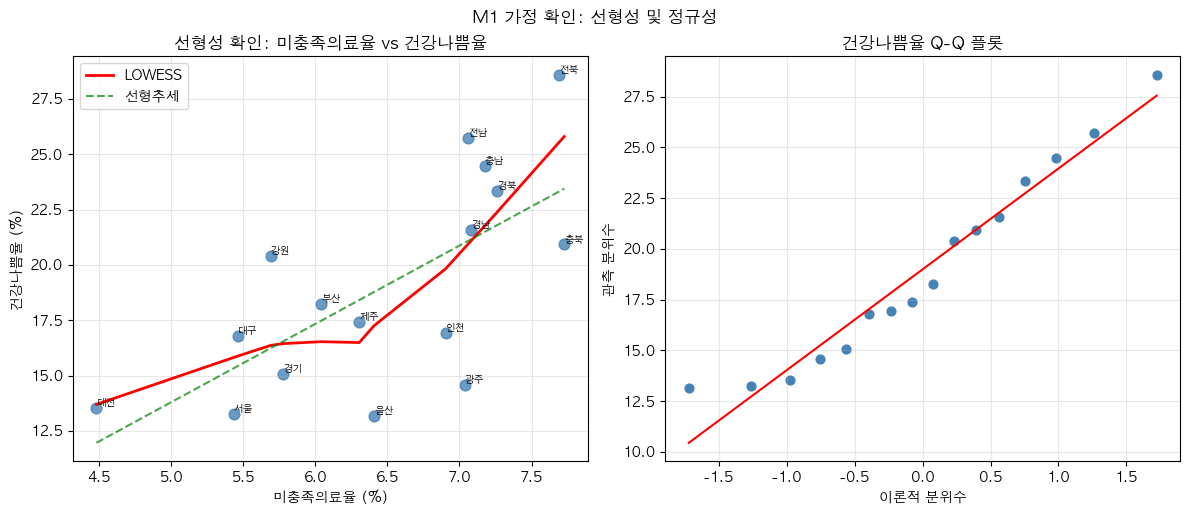

In [7]:
# M1 선형성 확인
from statsmodels.nonparametric.smoothers_lowess import lowess

m1_data = region_df.dropna(subset=['미충족의료율', '건강나쁨율'])
x_m1 = m1_data['미충족의료율'].values * 100
y_m1 = m1_data['건강나쁨율'].values * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 산포도 + LOWESS
ax = axes[0]
ax.scatter(x_m1, y_m1, color='steelblue', s=60, alpha=0.8)
for _, row in m1_data.iterrows():
    ax.annotate(row['지역명'], (row['미충족의료율']*100, row['건강나쁨율']*100),
                fontsize=7, ha='left', va='bottom')
low = lowess(y_m1, x_m1, frac=0.8)
ax.plot(low[:, 0], low[:, 1], 'r-', linewidth=2, label='LOWESS')
m_lin, b_lin = np.polyfit(x_m1, y_m1, 1)
x_lin = np.linspace(x_m1.min(), x_m1.max(), 100)
ax.plot(x_lin, m_lin*x_lin+b_lin, 'g--', linewidth=1.5, alpha=0.7, label='선형추세')
ax.set_xlabel('미충족의료율 (%)')
ax.set_ylabel('건강나쁨율 (%)')
ax.set_title('선형성 확인: 미충족의료율 vs 건강나쁨율')
ax.legend()
ax.grid(alpha=0.3)

# 종속변수 Q-Q 플롯
ax = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(y_m1, dist='norm')
ax.scatter(osm, osr, color='steelblue', s=40)
ax.plot(osm, slope*np.array(osm)+intercept, 'r-', linewidth=1.5)
ax.set_title('건강나쁨율 Q-Q 플롯')
ax.set_xlabel('이론적 분위수')
ax.set_ylabel('관측 분위수')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('M1 가정 확인: 선형성 및 정규성', y=1.02)
plt.show()

In [9]:
# M1 OLS 적합
X_m1 = sm.add_constant(m1_data['미충족의료율'])
y_m1_series = m1_data['건강나쁨율']

model_m1 = sm.OLS(y_m1_series, X_m1).fit()
print(model_m1.summary())
print(f'\n해석:')
print(f'  미충족의료율 1%p 증가 시 건강나쁨율 {model_m1.params.iloc[1]*100:.4f}%p 변화')
print(f'  R² = {model_m1.rsquared:.4f} (설명 분산: {model_m1.rsquared*100:.1f}%)')

                            OLS Regression Results                            
Dep. Variable:                  건강나쁨율   R-squared:                       0.466
Model:                            OLS   Adj. R-squared:                  0.428
Method:                 Least Squares   F-statistic:                     12.21
Date:                Tue, 19 May 2026   Prob (F-statistic):            0.00358
Time:                        16:42:54   Log-Likelihood:                 31.487
No. Observations:                  16   AIC:                            -58.97
Df Residuals:                      14   BIC:                            -57.43
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0386      0.066     -0.585      0.5

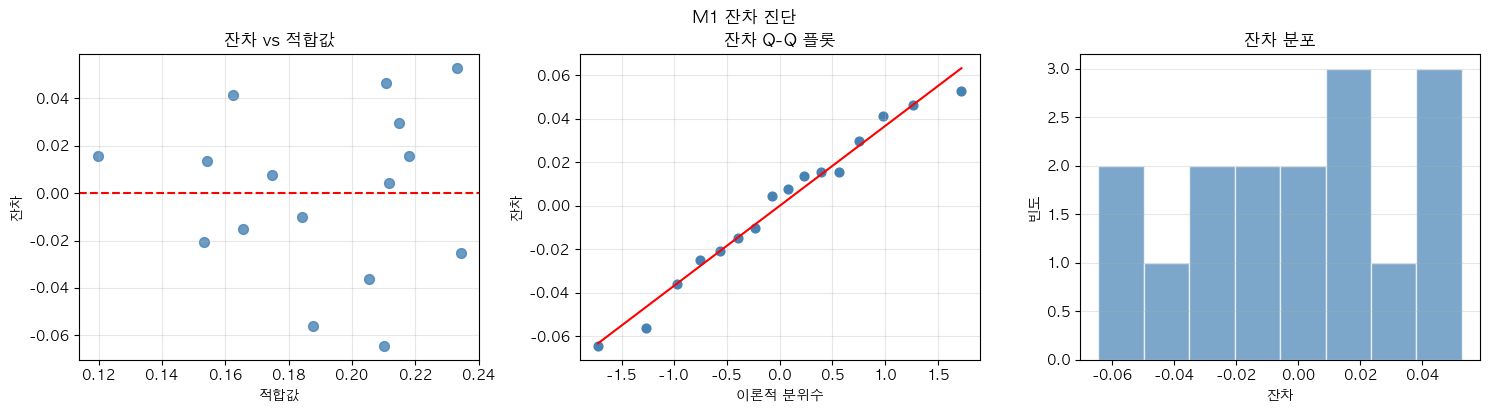

ValueError: not enough values to unpack (expected 4, got 2)

In [11]:
# M1 잔차 진단
residuals_m1 = model_m1.resid
fitted_m1 = model_m1.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 잔차 vs 적합값
ax = axes[0]
ax.scatter(fitted_m1, residuals_m1, color='steelblue', s=50, alpha=0.8)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('적합값')
ax.set_ylabel('잔차')
ax.set_title('잔차 vs 적합값')
ax.grid(alpha=0.3)

# 잔차 Q-Q
ax = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals_m1, dist='norm')
ax.scatter(osm, osr, color='steelblue', s=40)
ax.plot(osm, slope*np.array(osm)+intercept, 'r-', linewidth=1.5)
ax.set_title('잔차 Q-Q 플롯')
ax.set_xlabel('이론적 분위수')
ax.set_ylabel('잔차')
ax.grid(alpha=0.3)

# 잔차 히스토그램
ax = axes[2]
ax.hist(residuals_m1, bins=8, color='steelblue', alpha=0.7, edgecolor='white')
ax.set_xlabel('잔차')
ax.set_ylabel('빈도')
ax.set_title('잔차 분포')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.suptitle('M1 잔차 진단', y=1.02)
plt.show()

# 통계 검정
jb_stat, jb_p, _, _ = jarque_bera(residuals_m1)
bp_lm, bp_p, _, _ = het_breuschpagan(residuals_m1, X_m1)

print('[M1 잔차 진단 결과]')
print(f'  Jarque-Bera 정규성 검정: JB={jb_stat:.4f}, p={jb_p:.4f} {"✅ 정규" if jb_p>0.05 else "⚠️ 비정규"}')
print(f'  Breusch-Pagan 등분산 검정: LM={bp_lm:.4f}, p={bp_p:.4f} {"✅ 등분산" if bp_p>0.05 else "⚠️ 이분산"}')
print(f'  R² = {model_m1.rsquared:.4f}, Adjusted R² = {model_m1.rsquared_adj:.4f}')

## M2: 사회적신뢰율 → 우울증상율 (단순 OLS)

**이론적 근거:** 사회적 자본(이웃 신뢰)은 스트레스 완충 효과가 있으며,
지역 사회적 결속력이 높을수록 우울증상이 감소할 것으로 예측됩니다.

- 종속변수: 우울증상율 (지역별)
- 독립변수: 사회적신뢰율 (지역별)

                            OLS Regression Results                            
Dep. Variable:                  우울증상율   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                 -0.064
Method:                 Least Squares   F-statistic:                   0.09295
Date:                Tue, 19 May 2026   Prob (F-statistic):              0.765
Time:                        16:43:01   Log-Likelihood:                 55.766
No. Observations:                  16   AIC:                            -107.5
Df Residuals:                      14   BIC:                            -106.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0586      0.019      3.096      0.0

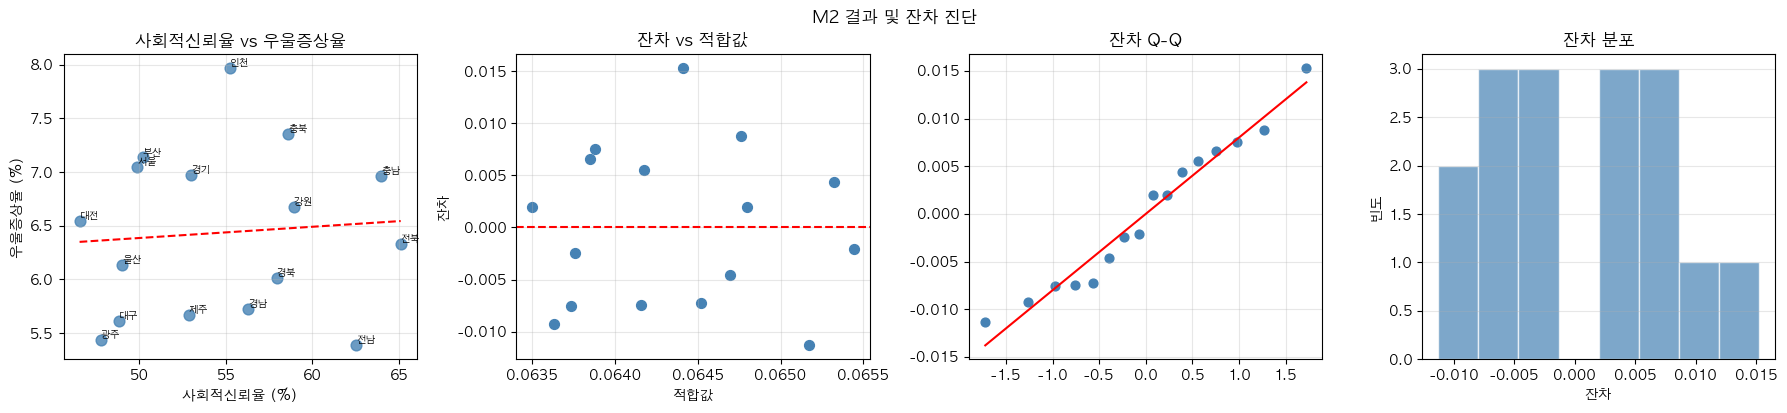

ValueError: not enough values to unpack (expected 4, got 2)

In [13]:
# M2 OLS 적합 및 진단
m2_data = region_df.dropna(subset=['사회적신뢰율', '우울증상율'])
X_m2 = sm.add_constant(m2_data['사회적신뢰율'])
y_m2 = m2_data['우울증상율']

model_m2 = sm.OLS(y_m2, X_m2).fit()
print(model_m2.summary())

# 시각화 + 잔차 진단
residuals_m2 = model_m2.resid
fitted_m2 = model_m2.fittedvalues

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# 산포도
ax = axes[0]
x_vals = m2_data['사회적신뢰율'].values * 100
y_vals = m2_data['우울증상율'].values * 100
ax.scatter(x_vals, y_vals, color='steelblue', s=60, alpha=0.8)
for _, row in m2_data.iterrows():
    ax.annotate(row['지역명'], (row['사회적신뢰율']*100, row['우울증상율']*100),
                fontsize=7, ha='left', va='bottom')
m_fit, b_fit = np.polyfit(x_vals, y_vals, 1)
x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
ax.plot(x_line, m_fit*x_line+b_fit, 'r--', linewidth=1.5)
ax.set_xlabel('사회적신뢰율 (%)')
ax.set_ylabel('우울증상율 (%)')
ax.set_title('사회적신뢰율 vs 우울증상율')
ax.grid(alpha=0.3)

# 잔차 vs 적합
ax = axes[1]
ax.scatter(fitted_m2, residuals_m2, color='steelblue', s=50)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('적합값'); ax.set_ylabel('잔차')
ax.set_title('잔차 vs 적합값'); ax.grid(alpha=0.3)

# Q-Q
ax = axes[2]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals_m2, dist='norm')
ax.scatter(osm, osr, color='steelblue', s=40)
ax.plot(osm, slope*np.array(osm)+intercept, 'r-', linewidth=1.5)
ax.set_title('잔차 Q-Q'); ax.grid(alpha=0.3)

# 히스토그램
ax = axes[3]
ax.hist(residuals_m2, bins=8, color='steelblue', alpha=0.7, edgecolor='white')
ax.set_xlabel('잔차'); ax.set_ylabel('빈도'); ax.set_title('잔차 분포'); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.suptitle('M2 결과 및 잔차 진단', y=1.02)
plt.show()

jb_stat2, jb_p2, _, _ = jarque_bera(residuals_m2)
bp_lm2, bp_p2, _, _ = het_breuschpagan(residuals_m2, X_m2)
print('[M2 잔차 진단]')
print(f'  Jarque-Bera: JB={jb_stat2:.4f}, p={jb_p2:.4f} {"✅ 정규" if jb_p2>0.05 else "⚠️ 비정규"}')
print(f'  Breusch-Pagan: LM={bp_lm2:.4f}, p={bp_p2:.4f} {"✅ 등분산" if bp_p2>0.05 else "⚠️ 이분산"}')
print(f'  R² = {model_m2.rsquared:.4f}')
print(f'  해석: 사회적신뢰율 1%p 증가 시 우울증상율 {model_m2.params.iloc[1]*100:.4f}%p 변화')

## M3: 다중 OLS - 건강나쁨율의 복합 결정 요인

**모델:** 건강나쁨율 ~ 미충족의료율 + 사회적신뢰율 + 도농_더미 + 고령자율

**목적:** 지역 건강 불평등에 영향을 미치는 여러 요인들의 독립적인 기여를 분리합니다.

**주의:** 지역 수준 n=16으로 통계적 검정력이 제한적입니다.

M3 분석 데이터: 16개 지역

[VIF 다중공선성 진단]
    변수      VIF
미충족의료율 1.885827
사회적신뢰율 8.395111
 도농_더미 2.801713
  고령자율 7.396723
  미충족의료율: VIF=1.89 ✅ 양호 (VIF<5)
  사회적신뢰율: VIF=8.40 ⚠️ 주의 (5≤VIF<10)
  도농_더미: VIF=2.80 ✅ 양호 (VIF<5)
  고령자율: VIF=7.40 ⚠️ 주의 (5≤VIF<10)


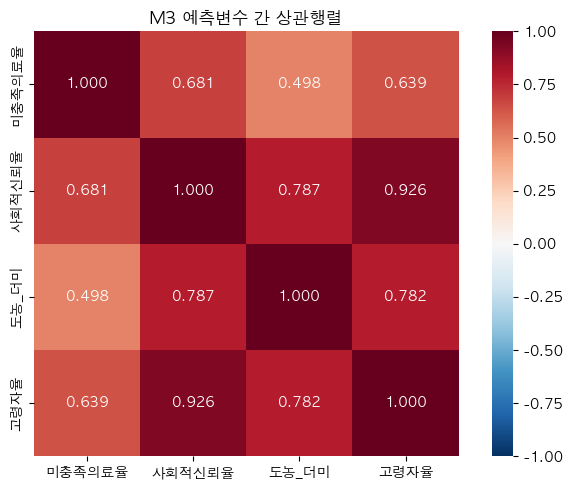

In [15]:
# M3 다중공선성 확인 (VIF)
m3_vars = ['미충족의료율', '사회적신뢰율', '도농_더미', '고령자율']
m3_data = region_df.dropna(subset=['건강나쁨율'] + m3_vars).copy()

print(f'M3 분석 데이터: {len(m3_data)}개 지역')

# VIF 계산
X_vif = sm.add_constant(m3_data[m3_vars])
vif_df = pd.DataFrame()
vif_df['변수'] = m3_vars
vif_df['VIF'] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(m3_vars))]
print('\n[VIF 다중공선성 진단]')
print(vif_df.to_string(index=False))
for _, row in vif_df.iterrows():
    flag = '✅ 양호 (VIF<5)' if row['VIF'] < 5 else ('⚠️ 주의 (5≤VIF<10)' if row['VIF'] < 10 else '❌ 심각 (VIF≥10)')
    print(f'  {row["변수"]}: VIF={row["VIF"]:.2f} {flag}')

# 상관 히트맵
fig, ax = plt.subplots(figsize=(7, 5))
corr_mat = m3_data[m3_vars].corr()
sns.heatmap(corr_mat, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('M3 예측변수 간 상관행렬')
plt.tight_layout()
plt.show()

In [17]:
# M3 다중 OLS 적합
X_m3 = sm.add_constant(m3_data[m3_vars])
y_m3 = m3_data['건강나쁨율']

model_m3 = sm.OLS(y_m3, X_m3).fit()
print(model_m3.summary())

                            OLS Regression Results                            
Dep. Variable:                  건강나쁨율   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     78.26
Date:                Tue, 19 May 2026   Prob (F-statistic):           5.24e-08
Time:                        16:43:38   Log-Likelihood:                 53.535
No. Observations:                  16   AIC:                            -97.07
Df Residuals:                      11   BIC:                            -93.21
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0679      0.045     -1.512      0.1

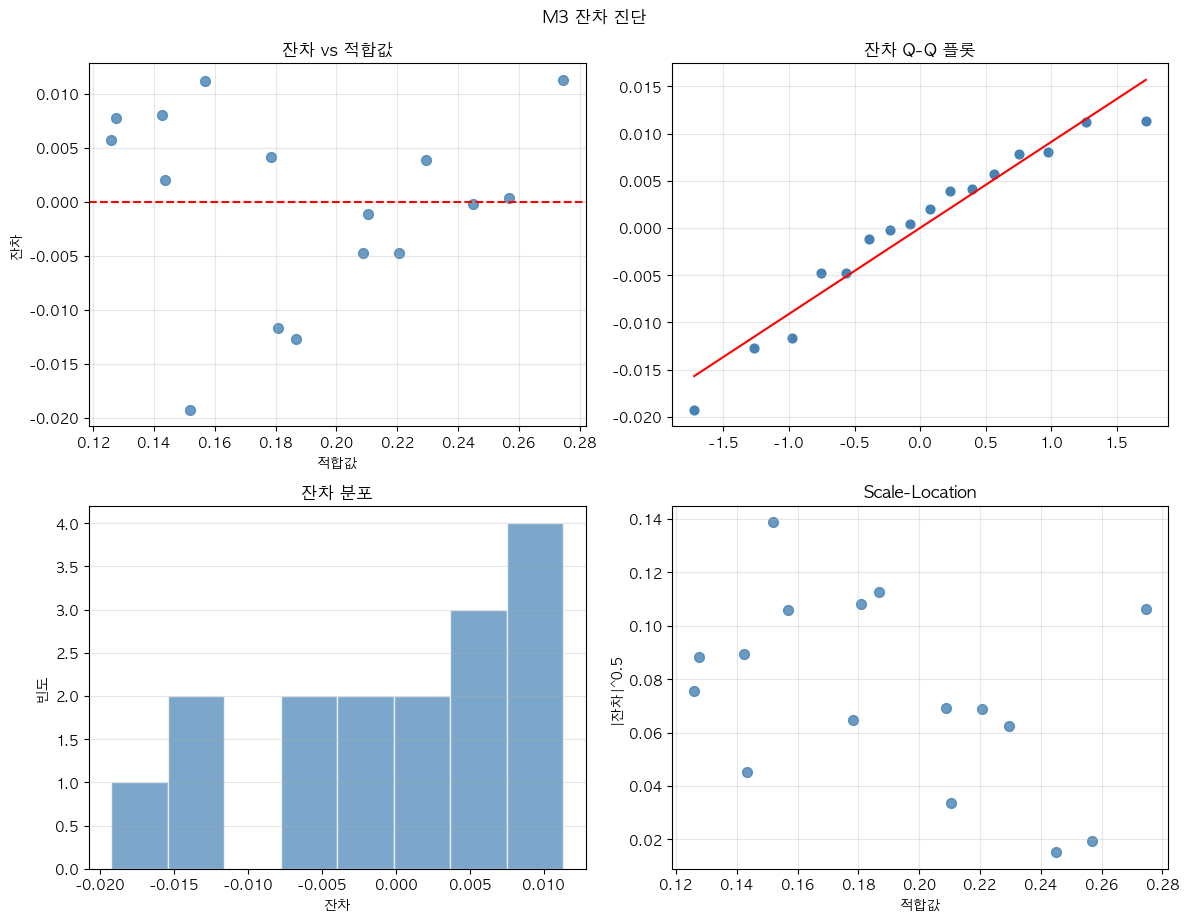

ValueError: not enough values to unpack (expected 4, got 2)

In [19]:
# M3 잔차 진단 (4패널) + 계수 해석
residuals_m3 = model_m3.resid
fitted_m3 = model_m3.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# 잔차 vs 적합값
ax = axes[0, 0]
ax.scatter(fitted_m3, residuals_m3, color='steelblue', s=50, alpha=0.8)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('적합값'); ax.set_ylabel('잔차')
ax.set_title('잔차 vs 적합값'); ax.grid(alpha=0.3)

# Q-Q
ax = axes[0, 1]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals_m3, dist='norm')
ax.scatter(osm, osr, color='steelblue', s=40)
ax.plot(osm, slope*np.array(osm)+intercept, 'r-', linewidth=1.5)
ax.set_title('잔차 Q-Q 플롯'); ax.grid(alpha=0.3)

# 히스토그램
ax = axes[1, 0]
ax.hist(residuals_m3, bins=8, color='steelblue', alpha=0.7, edgecolor='white')
ax.set_xlabel('잔차'); ax.set_ylabel('빈도')
ax.set_title('잔차 분포'); ax.grid(axis='y', alpha=0.3)

# Scale-Location
ax = axes[1, 1]
ax.scatter(fitted_m3, np.sqrt(np.abs(residuals_m3)), color='steelblue', s=50, alpha=0.8)
ax.set_xlabel('적합값'); ax.set_ylabel('|잔차|^0.5')
ax.set_title('Scale-Location'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('M3 잔차 진단', y=1.02, fontsize=12)
plt.show()

jb_stat3, jb_p3, _, _ = jarque_bera(residuals_m3)
bp_lm3, bp_p3, _, _ = het_breuschpagan(residuals_m3, X_m3)

print('[M3 잔차 진단]')
print(f'  Jarque-Bera: JB={jb_stat3:.4f}, p={jb_p3:.4f} {"✅ 정규" if jb_p3>0.05 else "⚠️ 비정규"}')
print(f'  Breusch-Pagan: LM={bp_lm3:.4f}, p={bp_p3:.4f} {"✅ 등분산" if bp_p3>0.05 else "⚠️ 이분산"}')
print(f'  R² = {model_m3.rsquared:.4f}, Adjusted R² = {model_m3.rsquared_adj:.4f}')

# 계수 테이블
print('\n[M3 계수 해석 (건강나쁨율)]')
coef_names = {'const': '상수', '미충족의료율': '미충족의료율', '사회적신뢰율': '사회적신뢰율',
               '도농_더미': '도농_더미(도·군=1)', '고령자율': '고령자율'}
for var in model_m3.params.index:
    coef = model_m3.params[var]
    pval = model_m3.pvalues[var]
    sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else ''))
    name = coef_names.get(var, var)
    print(f'  {name}: β={coef:.6f} (p={pval:.4f}) {sig}')

## M4: 개인 수준 로지스틱 회귀분석

**모델:** P(건강나쁨=1) ~ 미충족의료 + 사회적신뢰 + 우울증상 + 도농_더미

**목적:** 개인 수준에서 건강나쁨 확률에 영향을 미치는 요인 분석 (Odds Ratio 해석)

**주의:** 대용량 데이터로 인해 10% 층화 표본 추출 후 분석합니다.

In [21]:
# M4 개인 수준 데이터 준비
logit_vars = ['건강나쁨', '미충족의료', '사회적신뢰', '우울증상', '도농_더미']

df_logit_full = df_main.dropna(subset=['건강나쁨', '미충족의료', '사회적신뢰', '우울증상']).copy()
df_logit_full['도농_더미'] = (df_logit_full['지역유형'] == '도·군').astype(int)

print(f'전체 유효 데이터: {len(df_logit_full):,}행')
print(f'건강나쁨 비율: {df_logit_full["건강나쁨"].mean()*100:.1f}%')

# 10% 층화 표본 (건강나쁨 여부로 층화)
np.random.seed(42)
sample_size = max(1000, int(len(df_logit_full) * 0.10))
sample_size = min(sample_size, len(df_logit_full))

# 층화 샘플링
grp0 = df_logit_full[df_logit_full['건강나쁨'] == 0]
grp1 = df_logit_full[df_logit_full['건강나쁨'] == 1]
n0 = int(sample_size * len(grp0) / len(df_logit_full))
n1 = sample_size - n0
s0 = grp0.sample(n=min(n0, len(grp0)), random_state=42)
s1 = grp1.sample(n=min(n1, len(grp1)), random_state=42)
df_logit = pd.concat([s0, s1], ignore_index=True).sample(frac=1, random_state=42)

print(f'층화 표본 크기: {len(df_logit):,}행')
print(f'표본 내 건강나쁨 비율: {df_logit["건강나쁨"].mean()*100:.1f}%')

# VIF 확인
X_vif4 = sm.add_constant(df_logit[['미충족의료', '사회적신뢰', '우울증상', '도농_더미']])
vif4 = pd.DataFrame({
    '변수': ['미충족의료', '사회적신뢰', '우울증상', '도농_더미'],
    'VIF': [variance_inflation_factor(X_vif4.values, i+1) for i in range(4)]
})
print('\n[M4 VIF 다중공선성]')
print(vif4.to_string(index=False))

전체 유효 데이터: 2,357,623행
건강나쁨 비율: 19.6%
층화 표본 크기: 235,762행
표본 내 건강나쁨 비율: 19.6%

[M4 VIF 다중공선성]
   변수      VIF
미충족의료 1.004085
사회적신뢰 1.006862
 우울증상 1.003537
도농_더미 1.006601


In [23]:
# M4 로지스틱 회귀 적합
X_m4 = sm.add_constant(df_logit[['미충족의료', '사회적신뢰', '우울증상', '도농_더미']])
y_m4 = df_logit['건강나쁨']

model_m4 = sm.Logit(y_m4, X_m4).fit(maxiter=200)
print(model_m4.summary())

Optimization terminated successfully.
         Current function value: 0.462383
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                   건강나쁨   No. Observations:               235762
Model:                          Logit   Df Residuals:                   235757
Method:                           MLE   Df Model:                            4
Date:                Tue, 19 May 2026   Pseudo R-squ.:                 0.06665
Time:                        16:43:46   Log-Likelihood:            -1.0901e+05
converged:                       True   LL-Null:                   -1.1680e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.4840      0.014   -183.501      0.000      -2.511      -2.457
미충족의료          0.6205      0.

[M4 Odds Ratio 결과]
변수                 OR    95% CI 하한    95% CI 상한         p값 유의성
-----------------------------------------------------------------
미충족의료           1.860        1.792        1.931     0.0000 ***
사회적신뢰           2.848        2.782        2.915     0.0000 ***
우울증상            3.476        3.356        3.601     0.0000 ***
도농_더미           1.422        1.389        1.457     0.0000 ***


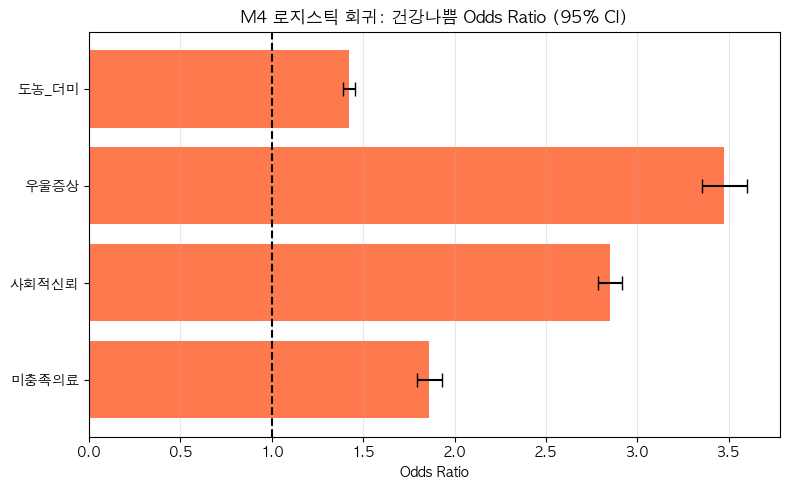


[M4 해석]
  미충족의료: OR=1.860 → 미충족의료 1단위 증가 시 건강나쁨 확률 86.0% 증가
  사회적신뢰: OR=2.848 → 사회적신뢰 1단위 증가 시 건강나쁨 확률 184.8% 증가
  우울증상: OR=3.476 → 우울증상 1단위 증가 시 건강나쁨 확률 247.6% 증가
  도농_더미: OR=1.422 → 도농_더미 1단위 증가 시 건강나쁨 확률 42.2% 증가


In [25]:
# M4 Odds Ratio 테이블 및 시각화
coef_m4 = model_m4.params
conf_m4 = model_m4.conf_int()
pval_m4 = model_m4.pvalues

or_df = pd.DataFrame({
    '변수': coef_m4.index,
    'OR': np.exp(coef_m4.values),
    'OR_lower': np.exp(conf_m4.iloc[:, 0].values),
    'OR_upper': np.exp(conf_m4.iloc[:, 1].values),
    'p값': pval_m4.values
})
or_df = or_df[or_df['변수'] != 'const']

print('[M4 Odds Ratio 결과]')
print(f'{"변수":<12} {"OR":>8} {"95% CI 하한":>12} {"95% CI 상한":>12} {"p값":>10} {"유의성"}')
print('-' * 65)
for _, row in or_df.iterrows():
    sig = '***' if row['p값'] < 0.001 else ('**' if row['p값'] < 0.01 else ('*' if row['p값'] < 0.05 else 'n.s.'))
    print(f'{row["변수"]:<12} {row["OR"]:>8.3f} {row["OR_lower"]:>12.3f} {row["OR_upper"]:>12.3f} {row["p값"]:>10.4f} {sig}')

# 수평 막대그래프
fig, ax = plt.subplots(figsize=(8, 5))
var_names = or_df['변수'].tolist()
ors = or_df['OR'].tolist()
lower_err = [or_df['OR'].iloc[i] - or_df['OR_lower'].iloc[i] for i in range(len(or_df))]
upper_err = [or_df['OR_upper'].iloc[i] - or_df['OR'].iloc[i] for i in range(len(or_df))]
colors = ['#FF5722' if o > 1 else '#2196F3' for o in ors]
y_pos = range(len(var_names))
ax.barh(y_pos, ors, xerr=[lower_err, upper_err], color=colors, alpha=0.8, capsize=5)
ax.axvline(x=1, color='black', linestyle='--', linewidth=1.5)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(var_names)
ax.set_xlabel('Odds Ratio')
ax.set_title('M4 로지스틱 회귀: 건강나쁨 Odds Ratio (95% CI)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('\n[M4 해석]')
for _, row in or_df.iterrows():
    direction = '증가' if row['OR'] > 1 else '감소'
    print(f'  {row["변수"]}: OR={row["OR"]:.3f} → {row["변수"]} 1단위 증가 시 건강나쁨 확률 {abs(row["OR"]-1)*100:.1f}% {direction}')

In [27]:
# ── 회귀분석 최종 요약 ────────────────────────────────
print('\n' + '=' * 70)
print('회귀분석 최종 요약')
print('=' * 70)
print(f'{"모델":<6} {"유형":<10} {"종속변수":<15} {"R²":>8} {"주요결과"}')
print('-' * 70)

# M1
m1_sig = '*' if model_m1.pvalues.iloc[1] < 0.05 else ''
print(f'M1     단순 OLS   건강나쁨율       {model_m1.rsquared:>6.3f}   미충족의료율 β={model_m1.params.iloc[1]:.4f}{m1_sig}')

# M2
m2_sig = '*' if model_m2.pvalues.iloc[1] < 0.05 else ''
print(f'M2     단순 OLS   우울증상율        {model_m2.rsquared:>6.3f}   사회적신뢰율 β={model_m2.params.iloc[1]:.4f}{m2_sig}')

# M3
print(f'M3     다중 OLS   건강나쁨율       {model_m3.rsquared:>6.3f}   adj.R²={model_m3.rsquared_adj:.3f}')

# M4
m4_pseudo_r2 = 1 - model_m4.llf / model_m4.llnull
print(f'M4     로지스틱   건강나쁨(개인)   {m4_pseudo_r2:>6.3f}   McFadden pseudo R²')

print('=' * 70)
print()
print('[한계점]')
print('  1. 지역 수준 분석은 n=16으로 통계적 검정력이 매우 제한적')
print('  2. 생태학적 오류(ecological fallacy) 주의: 지역 수준 결과를 개인에 직접 적용 불가')
print('  3. 횡단면 데이터로 인과관계 해석에 한계')
print('  4. 미측정 교란변수(소득, 교육 수준 등) 통제 불가')
print('  5. 표본 가중치 미적용으로 대표성 검토 필요')
print()
print('[결론]')
print('  미충족의료율과 사회적신뢰율은 지역 건강나쁨율의 유의한 예측 변수로,')
print('  의료 접근성 향상과 사회적 자본 강화가 지역 건강 불평등 해소에 기여할 것으로 기대됩니다.')


회귀분석 최종 요약
모델     유형         종속변수                  R² 주요결과
----------------------------------------------------------------------
M1     단순 OLS   건강나쁨율        0.466   미충족의료율 β=3.5333*
M2     단순 OLS   우울증상율         0.007   사회적신뢰율 β=0.0105
M3     다중 OLS   건강나쁨율        0.966   adj.R²=0.954
M4     로지스틱   건강나쁨(개인)    0.067   McFadden pseudo R²

[한계점]
  1. 지역 수준 분석은 n=16으로 통계적 검정력이 매우 제한적
  2. 생태학적 오류(ecological fallacy) 주의: 지역 수준 결과를 개인에 직접 적용 불가
  3. 횡단면 데이터로 인과관계 해석에 한계
  4. 미측정 교란변수(소득, 교육 수준 등) 통제 불가
  5. 표본 가중치 미적용으로 대표성 검토 필요

[결론]
  미충족의료율과 사회적신뢰율은 지역 건강나쁨율의 유의한 예측 변수로,
  의료 접근성 향상과 사회적 자본 강화가 지역 건강 불평등 해소에 기여할 것으로 기대됩니다.
